In [1]:
import pandas as pd

In [2]:
ls

Evictions_20240717.csv
Housing_Maintenance_Code_Violations_20240717.csv
Lede Project 2 Crashes.ipynb
Motor_Vehicle_Collisions_-_Crashes.csv
Motor_Vehicle_Collisions_-_Crashes_20240713.csv
Motor_Vehicle_Collisions_-_Person_20240715.csv
NPS - CY2007-Present Mortality Data.csv
NPS-Mortality-Data-Released-April-2024.xlsx
OLD/
Open_Streets_Locations.csv
accidents_data_cleaning.ipynb
accidents_data_visualization.ipynb
data/
evict_2017_df.csv
evict_2018_df.csv
evict_2019_df.csv
evict_2020_df.csv
evict_2021_df.csv
evict_2022_df.csv
evict_2023_df.csv
gis_1/
pc_crash_17_df.csv
pc_crash_21_df.csv
pc_crash_23_df.csv
project-2 TEST.ipynb
project-2-housing.ipynb


In [12]:
df = pd.read_csv("Housing_Maintenance_Code_Violations_20240717.csv")

/var/folders/nm/f3tycdwx20176n4gg7c1x5900000gn/T/ipykernel_1547/3659859973.py:1: DtypeWarning: Columns (10,12,23) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Housing_Maintenance_Code_Violations_20240717.csv")


## Filter ApprovedDate by year by creating a new column Year with only the last 4 characters of the string

In [16]:
df['Year'] = df['ApprovedDate'].apply(lambda x: x[-4:])

## Create new dataframe filtered for years 2017-2023

In [11]:
v_df = df[(df['Year'] >= '2017') & (df['Year'] < '2024') ]
v_df

,ViolationID,BuildingID,RegistrationID,BoroID,Borough,HouseNumber,LowHouseNumber,HighHouseNumber,StreetName,StreetCode,...,RentImpairing,Latitude,Longitude,CommunityBoard,CouncilDistrict,CensusTract,BIN,BBL,NTA,Year
23,14163924,95705,217816,2,BRONX,1744,1740,1744,MERRILL STREET,50620,...,N,40.836666,-73.869713,9.0,18.0,218.0,2028154.0,2.038960e+09,West Farms-Bronx River,2021
24,14162537,42537,102085,1,MANHATTAN,465,465,467,WEST 152 STREET,36810,...,N,40.829134,-73.943146,9.0,7.0,23501.0,1061612.0,1.020670e+09,Hamilton Heights,2021
29,14200045,484621,405810,4,QUEENS,37-40,37-36,37-40,81 STREET,16740,...,N,40.749307,-73.885187,3.0,25.0,283.0,4029990.0,4.012910e+09,Jackson Heights,2021
30,14201639,192102,300902,3,BROOKLYN,1215,1211,1223,AVENUE N,14280,...,N,40.615347,-73.962133,14.0,48.0,768.0,3180806.0,3.067410e+09,Midwood,2021
32,14203173,326554,308285,3,BROOKLYN,364,362,384,LINCOLN PLACE,56030,...,N,40.673040,-73.964094,8.0,35.0,215.0,3029627.0,3.011790e+09,Prospect Heights,2021
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9224720,16558584,639447,406030,4,QUEENS,42-60,42-60,42-60,BOWNE STREET,36590,...,N,40.755894,-73.820739,7.0,20.0,859.0,4117155.0,4.051860e+09,Flushing-Willets Point,2023
9224721,16558752,20629,140066,1,MANHATTAN,107,107,131,EAST 126 STREET,19470,...,N,40.805507,-73.937997,11.0,9.0,242.0,1054496.0,1.017750e+09,East Harlem (North),2023
9224722,16560611,97777,221417,2,BRONX,534,532,534,MORRIS PARK AVENUE,52220,...,N,40.842777,-73.871280,11.0,13.0,240.0,2042576.0,2.040190e+09,Pelham Parkway-Van Nest,2023
9229710,16016552,18911,109443,1,MANHATTAN,112,112,116,EAST 103 STREET,19030,...,Y,40.790721,-73.948675,11.0,8.0,166.0,1051905.0,1.016300e+09,East Harlem (South),2023


In [14]:
v_df.columns

Index(['ViolationID', 'BuildingID', 'RegistrationID', 'BoroID', 'Borough',
       'HouseNumber', 'LowHouseNumber', 'HighHouseNumber', 'StreetName',
       'StreetCode', 'Postcode', 'Apartment', 'Story', 'Block', 'Lot', 'Class',
       'InspectionDate', 'ApprovedDate', 'OriginalCertifyByDate',
       'OriginalCorrectByDate', 'NewCertifyByDate', 'NewCorrectByDate',
       'CertifiedDate', 'OrderNumber', 'NOVID', 'NOVDescription',
       'NOVIssuedDate', 'CurrentStatusID', 'CurrentStatus',
       'CurrentStatusDate', 'NovType', 'ViolationStatus', 'RentImpairing',
       'Latitude', 'Longitude', 'CommunityBoard', 'CouncilDistrict',
       'CensusTract', 'BIN', 'BBL', 'NTA', 'Year'],
      dtype='object')

## Get rid of columns that are not needed for the analysis

In [19]:
v_df = v_df.drop(['HouseNumber', 'LowHouseNumber', 'HighHouseNumber', 'Apartment', 'Story', 'NewCertifyByDate', 'NewCorrectByDate',
       'CertifiedDate', 'OrderNumber', 'CurrentStatusID', 'CurrentStatus',
       'CurrentStatusDate', 'NovType', 'ViolationStatus', 'RentImpairing'], axis=1)
v_df

,ViolationID,BuildingID,RegistrationID,BoroID,Borough,StreetName,StreetCode,Postcode,Block,Lot,...,NOVIssuedDate,Latitude,Longitude,CommunityBoard,CouncilDistrict,CensusTract,BIN,BBL,NTA,Year
23,14163924,95705,217816,2,BRONX,MERRILL STREET,50620,10460.0,3896,49,...,04/08/2021,40.836666,-73.869713,9.0,18.0,218.0,2028154.0,2.038960e+09,West Farms-Bronx River,2021
24,14162537,42537,102085,1,MANHATTAN,WEST 152 STREET,36810,10031.0,2067,12,...,05/19/2021,40.829134,-73.943146,9.0,7.0,23501.0,1061612.0,1.020670e+09,Hamilton Heights,2021
29,14200045,484621,405810,4,QUEENS,81 STREET,16740,11372.0,1291,25,...,04/16/2021,40.749307,-73.885187,3.0,25.0,283.0,4029990.0,4.012910e+09,Jackson Heights,2021
30,14201639,192102,300902,3,BROOKLYN,AVENUE N,14280,11230.0,6741,54,...,04/13/2021,40.615347,-73.962133,14.0,48.0,768.0,3180806.0,3.067410e+09,Midwood,2021
32,14203173,326554,308285,3,BROOKLYN,LINCOLN PLACE,56030,11238.0,1179,37,...,04/13/2021,40.673040,-73.964094,8.0,35.0,215.0,3029627.0,3.011790e+09,Prospect Heights,2021
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9224720,16558584,639447,406030,4,QUEENS,BOWNE STREET,36590,11355.0,5186,46,...,12/28/2023,40.755894,-73.820739,7.0,20.0,859.0,4117155.0,4.051860e+09,Flushing-Willets Point,2023
9224721,16558752,20629,140066,1,MANHATTAN,EAST 126 STREET,19470,10035.0,1775,6,...,12/28/2023,40.805507,-73.937997,11.0,9.0,242.0,1054496.0,1.017750e+09,East Harlem (North),2023
9224722,16560611,97777,221417,2,BRONX,MORRIS PARK AVENUE,52220,10460.0,4019,3,...,01/02/2024,40.842777,-73.871280,11.0,13.0,240.0,2042576.0,2.040190e+09,Pelham Parkway-Van Nest,2023
9229710,16016552,18911,109443,1,MANHATTAN,EAST 103 STREET,19030,10029.0,1630,69,...,06/05/2023,40.790721,-73.948675,11.0,8.0,166.0,1051905.0,1.016300e+09,East Harlem (South),2023


In [20]:
v_df.columns

Index(['ViolationID', 'BuildingID', 'RegistrationID', 'BoroID', 'Borough',
       'StreetName', 'StreetCode', 'Postcode', 'Block', 'Lot', 'Class',
       'InspectionDate', 'ApprovedDate', 'OriginalCertifyByDate',
       'OriginalCorrectByDate', 'NOVID', 'NOVDescription', 'NOVIssuedDate',
       'Latitude', 'Longitude', 'CommunityBoard', 'CouncilDistrict',
       'CensusTract', 'BIN', 'BBL', 'NTA', 'Year'],
      dtype='object')

In [32]:
v_df['CouncilDistrict'].value_counts().head(5)

CouncilDistrict
15.0    256034
40.0    227182
14.0    225990
16.0    211094
17.0    206675
Name: count, dtype: int64

In [21]:
v_df['Class'].value_counts()

Class
B    1978674
A    1206800
C    1129997
I     483819
Name: count, dtype: int64

In [22]:
v_df['Borough'].value_counts()

Borough
BROOKLYN         1850843
BRONX            1398617
MANHATTAN         914537
QUEENS            566031
STATEN ISLAND      69262
Name: count, dtype: int64

<Axes: xlabel='Year'>

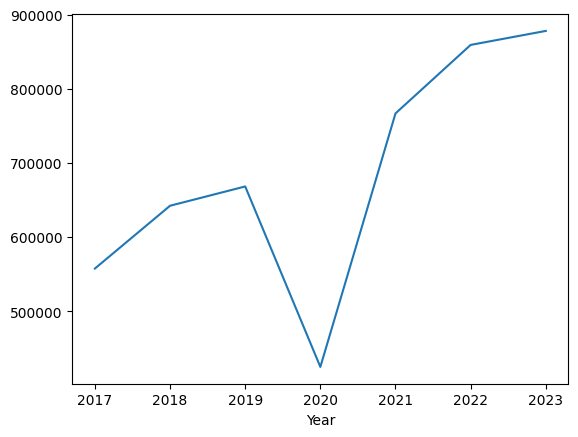

In [24]:
v_df['Year'].value_counts().sort_index().plot()

In [61]:
v_df['CouncilDistrict'].value_counts().head(10).to_frame()

,count
CouncilDistrict,
15.0,256034
40.0,227182
14.0,225990
16.0,211094
17.0,206675
10.0,203865
9.0,200804
41.0,192928
36.0,186597


In [26]:
v_d15_df = v_df[v_df['CouncilDistrict'] == 15.0]
v_d15_df

,ViolationID,BuildingID,RegistrationID,BoroID,Borough,StreetName,StreetCode,Postcode,Block,Lot,...,NOVIssuedDate,Latitude,Longitude,CommunityBoard,CouncilDistrict,CensusTract,BIN,BBL,NTA,Year
58,13948006,101337,209172,2,BRONX,PARK AVENUE,56820,10457.0,3030,159,...,12/18/2020,40.855498,-73.894857,6.0,15.0,38302.0,2011173.0,2.030300e+09,Fordham South,2020
59,13948007,101337,209172,2,BRONX,PARK AVENUE,56820,10457.0,3030,159,...,12/18/2020,40.855498,-73.894857,6.0,15.0,38302.0,2011173.0,2.030300e+09,Fordham South,2020
153,13795848,115544,209780,2,BRONX,TOPPING AVENUE,69220,10457.0,2791,44,...,09/03/2020,40.844395,-73.905801,4.0,15.0,22902.0,2007349.0,2.027910e+09,Mount Hope,2020
230,14363299,87328,224814,2,BRONX,HUGHES AVENUE,41320,10458.0,3074,19,...,06/01/2021,40.854821,-73.887181,6.0,15.0,391.0,2092257.0,2.030740e+09,Belmont,2021
293,13960303,65704,205477,2,BRONX,EAST 175 STREET,26910,10457.0,2796,28,...,12/28/2020,40.846798,-73.908111,5.0,15.0,22901.0,2007424.0,2.027960e+09,Mount Hope,2020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9224685,16540863,47139,209567,2,BRONX,BARKER AVENUE,10420,10467.0,4340,78,...,12/26/2023,40.859491,-73.869509,11.0,15.0,33201.0,2049750.0,2.043400e+09,Allerton,2023
9224686,16540865,47139,209567,2,BRONX,BARKER AVENUE,10420,10467.0,4340,78,...,12/26/2023,40.859491,-73.869509,11.0,15.0,33201.0,2049750.0,2.043400e+09,Allerton,2023
9224687,16540876,47139,209567,2,BRONX,BARKER AVENUE,10420,10467.0,4340,78,...,12/29/2023,40.859491,-73.869509,11.0,15.0,33201.0,2049750.0,2.043400e+09,Allerton,2023
9224688,16540877,47139,209567,2,BRONX,BARKER AVENUE,10420,10467.0,4340,78,...,12/29/2023,40.859491,-73.869509,11.0,15.0,33201.0,2049750.0,2.043400e+09,Allerton,2023


In [27]:
v_d15_df['Class'].value_counts()

Class
B    120796
C     72419
A     54819
I      8000
Name: count, dtype: int64

In [28]:
v_d40_df = v_df[v_df['CouncilDistrict'] == 40.0]
v_d40_df

,ViolationID,BuildingID,RegistrationID,BoroID,Borough,StreetName,StreetCode,Postcode,Block,Lot,...,NOVIssuedDate,Latitude,Longitude,CommunityBoard,CouncilDistrict,CensusTract,BIN,BBL,NTA,Year
213,14351601,332240,337002,3,BROOKLYN,MAPLE STREET,58530,11225.0,4796,26,...,05/24/2021,40.660905,-73.949222,9.0,40.0,804.0,3106651.0,3.047960e+09,Prospect Lefferts Gardens-Wingate,2021
219,14356397,934656,383521,3,BROOKLYN,CATON AVENUE,25130,11226.0,5083,7502,...,05/25/2021,40.652781,-73.956775,14.0,40.0,79602.0,3396958.0,3.050838e+09,Prospect Lefferts Gardens-Wingate,2021
296,13961743,233920,306471,3,BROOKLYN,DORCHESTER ROAD,33530,11226.0,5163,33,...,12/29/2020,40.641594,-73.959139,14.0,40.0,51602.0,3118822.0,3.051630e+09,Flatbush,2020
297,13961745,233920,306471,3,BROOKLYN,DORCHESTER ROAD,33530,11226.0,5163,33,...,12/29/2020,40.641594,-73.959139,14.0,40.0,51602.0,3118822.0,3.051630e+09,Flatbush,2020
298,13961746,233920,306471,3,BROOKLYN,DORCHESTER ROAD,33530,11226.0,5163,33,...,12/29/2020,40.641594,-73.959139,14.0,40.0,51602.0,3118822.0,3.051630e+09,Flatbush,2020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9224639,16507706,220379,327069,3,BROOKLYN,CHURCH AVENUE,26230,11203.0,4879,41,...,12/11/2023,40.651392,-73.937939,17.0,40.0,872.0,3109036.0,3.048790e+09,East Flatbush-Rugby,2023
9224640,16507707,220379,327069,3,BROOKLYN,CHURCH AVENUE,26230,11203.0,4879,41,...,12/11/2023,40.651392,-73.937939,17.0,40.0,872.0,3109036.0,3.048790e+09,East Flatbush-Rugby,2023
9224641,16507709,220379,327069,3,BROOKLYN,CHURCH AVENUE,26230,11203.0,4879,41,...,12/11/2023,40.651392,-73.937939,17.0,40.0,872.0,3109036.0,3.048790e+09,East Flatbush-Rugby,2023
9224683,16540467,380933,345356,3,BROOKLYN,TENNIS COURT,84730,11226.0,5099,139,...,12/26/2023,40.648567,-73.961524,14.0,40.0,51002.0,3117121.0,3.050990e+09,Flatbush,2023


In [29]:
v_d40_df['Class'].value_counts()

Class
B    110635
C     59174
A     50679
I      6694
Name: count, dtype: int64

In [30]:
v_d14_df = v_df[v_df['CouncilDistrict'] == 14.0]
v_d14_df

,ViolationID,BuildingID,RegistrationID,BoroID,Borough,StreetName,StreetCode,Postcode,Block,Lot,...,NOVIssuedDate,Latitude,Longitude,CommunityBoard,CouncilDistrict,CensusTract,BIN,BBL,NTA,Year
145,13075848,81701,203970,2,BRONX,GRAND CONCOURSE,36420,10457.0,2832,40,...,05/20/2019,40.840612,-73.912796,4.0,14.0,225.0,2007993.0,2.028320e+09,East Concourse-Concourse Village,2019
146,13075849,81701,203970,2,BRONX,GRAND CONCOURSE,36420,10457.0,2832,40,...,05/20/2019,40.840612,-73.912796,4.0,14.0,225.0,2007993.0,2.028320e+09,East Concourse-Concourse Village,2019
147,13075850,81701,203970,2,BRONX,GRAND CONCOURSE,36420,10457.0,2832,40,...,05/20/2019,40.840612,-73.912796,4.0,14.0,225.0,2007993.0,2.028320e+09,East Concourse-Concourse Village,2019
234,13909065,81701,203970,2,BRONX,GRAND CONCOURSE,36420,10457.0,2832,40,...,11/23/2020,40.840612,-73.912796,4.0,14.0,225.0,2007993.0,2.028320e+09,East Concourse-Concourse Village,2020
238,13903647,108439,210118,2,BRONX,SEDGWICK AVENUE,63820,10453.0,2879,149,...,11/19/2020,40.852896,-73.918086,5.0,14.0,24501.0,2009103.0,2.028790e+09,University Heights-Morris Heights,2020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9224647,16521625,60496,200754,2,BRONX,DAVIDSON AVENUE,23520,10468.0,3197,23,...,12/15/2023,40.859111,-73.904602,7.0,14.0,239.0,2014233.0,2.031970e+09,Fordham Heights,2023
9224648,16522729,60496,200754,2,BRONX,DAVIDSON AVENUE,23520,10468.0,3197,23,...,12/12/2023,40.859111,-73.904602,7.0,14.0,239.0,2014233.0,2.031970e+09,Fordham Heights,2023
9224650,16528704,60496,200754,2,BRONX,DAVIDSON AVENUE,23520,10468.0,3197,23,...,12/19/2023,40.859111,-73.904602,7.0,14.0,239.0,2014233.0,2.031970e+09,Fordham Heights,2023
9224672,16538734,60496,200754,2,BRONX,DAVIDSON AVENUE,23520,10468.0,3197,23,...,12/20/2023,40.859111,-73.904602,7.0,14.0,239.0,2014233.0,2.031970e+09,Fordham Heights,2023


In [31]:
v_d14_df['Class'].value_counts()

Class
B    109966
C     65806
A     46586
I      3632
Name: count, dtype: int64

In [33]:
v_d16_df = v_df[v_df['CouncilDistrict'] == 16.0]
v_d16_df

,ViolationID,BuildingID,RegistrationID,BoroID,Borough,StreetName,StreetCode,Postcode,Block,Lot,...,NOVIssuedDate,Latitude,Longitude,CommunityBoard,CouncilDistrict,CensusTract,BIN,BBL,NTA,Year
83,14049084,88751,204653,2,BRONX,JEROME AVENUE,42820,10452.0,2505,84,...,03/03/2021,40.834637,-73.924299,4.0,16.0,199.0,2003072.0,2.025050e+09,Highbridge,2021
140,14315288,108415,221729,2,BRONX,SEDGWICK AVENUE,63820,10453.0,2880,17,...,04/30/2021,40.846785,-73.924929,5.0,16.0,20501.0,2009171.0,2.028800e+09,University Heights-Morris Heights,2021
315,13066897,80073,200742,2,BRONX,GERARD AVENUE,35020,10452.0,2478,18,...,05/14/2019,40.832618,-73.921927,4.0,16.0,195.0,2002946.0,2.024780e+09,Concourse-Concourse Village,2019
361,14401807,109462,211133,2,BRONX,SHERIDAN AVENUE,64620,10457.0,2821,61,...,06/24/2021,40.842019,-73.911081,4.0,16.0,225.0,2007854.0,2.028210e+09,East Concourse-Concourse Village,2021
409,14413739,112730,215361,2,BRONX,TELLER AVENUE,67820,10456.0,2433,76,...,07/02/2021,40.828706,-73.913747,4.0,16.0,175.0,2002247.0,2.024330e+09,East Concourse-Concourse Village,2021
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9224495,16308197,927224,227405,2,BRONX,EAST CLARKE PLACE,19920,10452.0,2839,10,...,10/16/2023,40.838152,-73.918451,4.0,16.0,22101.0,2127532.0,2.028390e+09,Mount Eden-Claremont (West),2023
9224515,16344228,80077,211142,2,BRONX,GERARD AVENUE,35020,10452.0,2488,41,...,10/30/2023,40.834530,-73.920826,4.0,16.0,197.0,2003003.0,2.024880e+09,Concourse-Concourse Village,2023
9224574,16427042,80096,204987,2,BRONX,GERARD AVENUE,35020,10451.0,2473,1,...,11/21/2023,40.823586,-73.927231,4.0,16.0,6301.0,2002894.0,2.024730e+09,Concourse-Concourse Village,2023
9224632,16503549,842309,223071,2,BRONX,CLINTON AVENUE,20220,10456.0,2934,23,...,12/07/2023,40.832711,-73.899776,3.0,16.0,151.0,2114113.0,2.029340e+09,Morrisania,2023


In [34]:
v_d16_df['Class'].value_counts()

Class
B    102258
C     59026
A     45044
I      4766
Name: count, dtype: int64

In [35]:
v_d17_df = v_df[v_df['CouncilDistrict'] == 17.0]
v_d17_df

,ViolationID,BuildingID,RegistrationID,BoroID,Borough,StreetName,StreetCode,Postcode,Block,Lot,...,NOVIssuedDate,Latitude,Longitude,CommunityBoard,CouncilDistrict,CensusTract,BIN,BBL,NTA,Year
214,14348310,108749,201330,2,BRONX,SENECA AVENUE,64020,10474.0,2762,7501,...,05/20/2021,40.818940,-73.886981,2.0,17.0,11502.0,2006460.0,2.027628e+09,Hunts Point,2021
291,11749900,114967,205055,2,BRONX,TIFFANY STREET,68720,10459.0,2706,60,...,04/28/2017,40.826830,-73.894964,2.0,17.0,131.0,2005503.0,2.027060e+09,Longwood,2017
334,14398289,52090,213349,2,BRONX,BRONX RIVER AVENUE,15420,10472.0,3769,41,...,06/21/2021,40.829686,-73.882493,9.0,17.0,54.0,2024953.0,2.037690e+09,West Farms-Bronx River,2021
362,12095372,114967,205055,2,BRONX,TIFFANY STREET,68720,10459.0,2706,60,...,11/27/2017,40.826830,-73.894964,2.0,17.0,131.0,2005503.0,2.027060e+09,Longwood,2017
369,12211007,86482,714688,2,BRONX,HOME STREET,40520,10459.0,2692,43,...,NaN,40.828179,-73.895952,2.0,17.0,131.0,2005286.0,2.026920e+09,Longwood,2018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9224227,15929216,65192,201961,2,BRONX,EAST 169 STREET,26730,10456.0,2615,29,...,04/19/2023,40.831317,-73.901006,3.0,17.0,149.0,2004304.0,2.026150e+09,Morrisania,2023
9224437,16176605,915629,225990,2,BRONX,MELROSE AVENUE,50320,10451.0,2404,7501,...,08/21/2023,40.821953,-73.915042,1.0,17.0,69.0,2117805.0,2.024048e+09,Melrose,2023
9224492,16307412,115202,713878,2,BRONX,TINTON AVENUE,69020,10456.0,2663,48,...,10/16/2023,40.829994,-73.900087,3.0,17.0,151.0,2004762.0,2.026630e+09,Morrisania,2023
9224502,16547665,806848,221415,2,BRONX,MORRISON AVENUE,52320,10473.0,3627,20,...,12/28/2023,40.821609,-73.872835,9.0,17.0,28.0,2092726.0,2.036270e+09,Soundview-Bruckner-Bronx River,2023


In [36]:
v_d17_df['Class'].value_counts()

Class
B    93845
C    56040
A    46490
I    10300
Name: count, dtype: int64

In [40]:
v_2023_df = v_df[v_df['Year'] == '2023']
v_2023_df

,ViolationID,BuildingID,RegistrationID,BoroID,Borough,StreetName,StreetCode,Postcode,Block,Lot,...,NOVIssuedDate,Latitude,Longitude,CommunityBoard,CouncilDistrict,CensusTract,BIN,BBL,NTA,Year
1773,15830498,234907,321115,3,BROOKLYN,DUMONT AVENUE,34330,11207.0,3810,28,...,03/22/2023,40.666936,-73.890083,5.0,42.0,1124.0,3084787.0,3.038100e+09,East New York,2023
2369,15669532,314783,352656,3,BROOKLYN,HULL STREET,51430,11233.0,1540,18,...,01/19/2023,40.679931,-73.907400,16.0,37.0,369.0,3041964.0,3.015400e+09,Ocean Hill,2023
5870,15830504,234961,369032,3,BROOKLYN,DUMONT AVENUE,34330,11207.0,4064,54,...,03/22/2023,40.667958,-73.883304,5.0,42.0,1162.0,3090129.0,3.040640e+09,East New York,2023
6323,15830505,234968,346131,3,BROOKLYN,DUMONT AVENUE,34330,11207.0,4080,28,...,03/22/2023,40.667974,-73.883074,5.0,42.0,1120.0,3090539.0,3.040800e+09,East New York,2023
6378,15830506,288432,367979,3,BROOKLYN,ELDERT STREET,38630,11207.0,3409,43,...,03/22/2023,40.687689,-73.912134,4.0,37.0,401.0,3078776.0,3.034090e+09,Bushwick South,2023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9224720,16558584,639447,406030,4,QUEENS,BOWNE STREET,36590,11355.0,5186,46,...,12/28/2023,40.755894,-73.820739,7.0,20.0,859.0,4117155.0,4.051860e+09,Flushing-Willets Point,2023
9224721,16558752,20629,140066,1,MANHATTAN,EAST 126 STREET,19470,10035.0,1775,6,...,12/28/2023,40.805507,-73.937997,11.0,9.0,242.0,1054496.0,1.017750e+09,East Harlem (North),2023
9224722,16560611,97777,221417,2,BRONX,MORRIS PARK AVENUE,52220,10460.0,4019,3,...,01/02/2024,40.842777,-73.871280,11.0,13.0,240.0,2042576.0,2.040190e+09,Pelham Parkway-Van Nest,2023
9229710,16016552,18911,109443,1,MANHATTAN,EAST 103 STREET,19030,10029.0,1630,69,...,06/05/2023,40.790721,-73.948675,11.0,8.0,166.0,1051905.0,1.016300e+09,East Harlem (South),2023


In [44]:
v_2023_df['CouncilDistrict'].value_counts().head()

CouncilDistrict
15.0    49175
14.0    42465
40.0    40862
16.0    40010
17.0    39477
Name: count, dtype: int64

In [41]:
v_2023_df.to_csv("v_2023_df.csv")

In [43]:
v_2017_df = v_df[v_df['Year'] == '2017']
v_2017_df

,ViolationID,BuildingID,RegistrationID,BoroID,Borough,StreetName,StreetCode,Postcode,Block,Lot,...,NOVIssuedDate,Latitude,Longitude,CommunityBoard,CouncilDistrict,CensusTract,BIN,BBL,NTA,Year
237,11609470,548147,0,4,QUEENS,135 STREET,22240,11420.0,11699,49,...,01/17/2017,40.677030,-73.804414,10.0,28.0,180.0,4253188.0,4.116990e+09,South Ozone Park,2017
249,11609472,548147,0,4,QUEENS,135 STREET,22240,11420.0,11699,49,...,01/17/2017,40.677030,-73.804414,10.0,28.0,180.0,4253188.0,4.116990e+09,South Ozone Park,2017
252,11610827,548147,0,4,QUEENS,135 STREET,22240,11420.0,11699,49,...,NaN,40.677030,-73.804414,10.0,28.0,180.0,4253188.0,4.116990e+09,South Ozone Park,2017
282,11737818,563280,419008,4,QUEENS,156 STREET,23740,11433.0,10124,38,...,04/18/2017,40.696792,-73.798045,12.0,28.0,254.0,4215746.0,4.101240e+09,South Jamaica,2017
283,11737829,563280,419008,4,QUEENS,156 STREET,23740,11433.0,10124,38,...,04/18/2017,40.696792,-73.798045,12.0,28.0,254.0,4215746.0,4.101240e+09,South Jamaica,2017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9211193,12134652,687226,400002,4,QUEENS,PARSONS BOULEVARD,58590,11354.0,4995,1,...,12/11/2017,40.766623,-73.823883,7.0,20.0,1159.0,4113027.0,4.049950e+09,Murray Hill-Broadway Flushing,2017
9211194,12162139,687226,400002,4,QUEENS,PARSONS BOULEVARD,58590,11354.0,4995,1,...,01/02/2018,40.766623,-73.823883,7.0,20.0,1159.0,4113027.0,4.049950e+09,Murray Hill-Broadway Flushing,2017
9211195,12165735,687226,400002,4,QUEENS,PARSONS BOULEVARD,58590,11354.0,4995,1,...,01/02/2018,40.766623,-73.823883,7.0,20.0,1159.0,4113027.0,4.049950e+09,Murray Hill-Broadway Flushing,2017
9211196,12165736,687226,400002,4,QUEENS,PARSONS BOULEVARD,58590,11354.0,4995,1,...,01/02/2018,40.766623,-73.823883,7.0,20.0,1159.0,4113027.0,4.049950e+09,Murray Hill-Broadway Flushing,2017


In [46]:
v_2017_df['CouncilDistrict'].value_counts().head()

CouncilDistrict
15.0    32520
14.0    32430
10.0    29303
16.0    27809
17.0    24746
Name: count, dtype: int64

In [47]:
v_2018_df = v_df[v_df['Year'] == '2018']
v_2018_df

,ViolationID,BuildingID,RegistrationID,BoroID,Borough,StreetName,StreetCode,Postcode,Block,Lot,...,NOVIssuedDate,Latitude,Longitude,CommunityBoard,CouncilDistrict,CensusTract,BIN,BBL,NTA,Year
363,12191080,879456,0,5,STATEN ISLAND,SENECA STREET,47450,10310.0,216,73,...,NaN,40.631619,-74.117918,1.0,49.0,125.0,5147984.0,5.002160e+09,West New Brighton-New Brighton-St. George,2018
369,12211007,86482,714688,2,BRONX,HOME STREET,40520,10459.0,2692,43,...,NaN,40.828179,-73.895952,2.0,17.0,131.0,2005286.0,2.026920e+09,Longwood,2018
387,12216167,340051,306988,3,BROOKLYN,MONTGOMERY STREET,62330,11213.0,1418,49,...,01/31/2018,40.664552,-73.935194,9.0,35.0,355.0,3038244.0,3.014180e+09,Crown Heights South,2018
389,12305707,114967,205055,2,BRONX,TIFFANY STREET,68720,10459.0,2706,60,...,03/28/2018,40.826830,-73.894964,2.0,17.0,131.0,2005503.0,2.027060e+09,Longwood,2018
395,12352540,340051,306988,3,BROOKLYN,MONTGOMERY STREET,62330,11213.0,1418,49,...,04/26/2018,40.664552,-73.935194,9.0,35.0,355.0,3038244.0,3.014180e+09,Crown Heights South,2018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9211476,12820601,687226,400002,4,QUEENS,PARSONS BOULEVARD,58590,11354.0,4995,1,...,12/24/2018,40.766623,-73.823883,7.0,20.0,1159.0,4113027.0,4.049950e+09,Murray Hill-Broadway Flushing,2018
9211477,12820604,687226,400002,4,QUEENS,PARSONS BOULEVARD,58590,11354.0,4995,1,...,12/24/2018,40.766623,-73.823883,7.0,20.0,1159.0,4113027.0,4.049950e+09,Murray Hill-Broadway Flushing,2018
9211478,12820605,687226,400002,4,QUEENS,PARSONS BOULEVARD,58590,11354.0,4995,1,...,12/24/2018,40.766623,-73.823883,7.0,20.0,1159.0,4113027.0,4.049950e+09,Murray Hill-Broadway Flushing,2018
9211479,12820606,687226,400002,4,QUEENS,PARSONS BOULEVARD,58590,11354.0,4995,1,...,12/24/2018,40.766623,-73.823883,7.0,20.0,1159.0,4113027.0,4.049950e+09,Murray Hill-Broadway Flushing,2018


In [48]:
v_2018_df['CouncilDistrict'].value_counts().head()

CouncilDistrict
15.0    35209
14.0    32540
40.0    29703
10.0    29551
16.0    28216
Name: count, dtype: int64

In [49]:
v_2019_df = v_df[v_df['Year'] == '2019']
v_2019_df

,ViolationID,BuildingID,RegistrationID,BoroID,Borough,StreetName,StreetCode,Postcode,Block,Lot,...,NOVIssuedDate,Latitude,Longitude,CommunityBoard,CouncilDistrict,CensusTract,BIN,BBL,NTA,Year
37,12915832,347379,305459,3,BROOKLYN,OCEAN AVENUE,67530,11230.0,6767,74,...,02/19/2019,40.612377,-73.953858,14.0,48.0,546.0,3182099.0,3.067670e+09,Midwood,2019
145,13075848,81701,203970,2,BRONX,GRAND CONCOURSE,36420,10457.0,2832,40,...,05/20/2019,40.840612,-73.912796,4.0,14.0,225.0,2007993.0,2.028320e+09,East Concourse-Concourse Village,2019
146,13075849,81701,203970,2,BRONX,GRAND CONCOURSE,36420,10457.0,2832,40,...,05/20/2019,40.840612,-73.912796,4.0,14.0,225.0,2007993.0,2.028320e+09,East Concourse-Concourse Village,2019
147,13075850,81701,203970,2,BRONX,GRAND CONCOURSE,36420,10457.0,2832,40,...,05/20/2019,40.840612,-73.912796,4.0,14.0,225.0,2007993.0,2.028320e+09,East Concourse-Concourse Village,2019
315,13066897,80073,200742,2,BRONX,GERARD AVENUE,35020,10452.0,2478,18,...,05/14/2019,40.832618,-73.921927,4.0,16.0,195.0,2002946.0,2.024780e+09,Concourse-Concourse Village,2019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9212937,13515660,687226,400002,4,QUEENS,PARSONS BOULEVARD,58590,11354.0,4995,1,...,12/26/2019,40.766623,-73.823883,7.0,20.0,1159.0,4113027.0,4.049950e+09,Murray Hill-Broadway Flushing,2019
9212938,13515723,687226,400002,4,QUEENS,PARSONS BOULEVARD,58590,11354.0,4995,1,...,12/26/2019,40.766623,-73.823883,7.0,20.0,1159.0,4113027.0,4.049950e+09,Murray Hill-Broadway Flushing,2019
9212939,13515726,687226,400002,4,QUEENS,PARSONS BOULEVARD,58590,11354.0,4995,1,...,12/26/2019,40.766623,-73.823883,7.0,20.0,1159.0,4113027.0,4.049950e+09,Murray Hill-Broadway Flushing,2019
9212940,13515727,687226,400002,4,QUEENS,PARSONS BOULEVARD,58590,11354.0,4995,1,...,12/26/2019,40.766623,-73.823883,7.0,20.0,1159.0,4113027.0,4.049950e+09,Murray Hill-Broadway Flushing,2019


In [50]:
v_2019_df['CouncilDistrict'].value_counts().head()

CouncilDistrict
15.0    36797
40.0    36179
14.0    32793
10.0    31531
16.0    30288
Name: count, dtype: int64

In [51]:
v_2020_df = v_df[v_df['Year'] == '2020']
v_2020_df

,ViolationID,BuildingID,RegistrationID,BoroID,Borough,StreetName,StreetCode,Postcode,Block,Lot,...,NOVIssuedDate,Latitude,Longitude,CommunityBoard,CouncilDistrict,CensusTract,BIN,BBL,NTA,Year
56,13940473,363196,303800,3,BROOKLYN,ROCKAWAY PARKWAY,73480,11212.0,4694,38,...,12/18/2020,40.657636,-73.916225,17.0,42.0,890.0,3102724.0,3.046940e+09,Rugby-Remsen Village,2020
57,13947557,268557,350988,3,BROOKLYN,EAST 52 STREET,37080,11203.0,4699,15,...,12/18/2020,40.651441,-73.928406,17.0,41.0,862.0,3102896.0,3.046990e+09,Rugby-Remsen Village,2020
58,13948006,101337,209172,2,BRONX,PARK AVENUE,56820,10457.0,3030,159,...,12/18/2020,40.855498,-73.894857,6.0,15.0,38302.0,2011173.0,2.030300e+09,Fordham South,2020
59,13948007,101337,209172,2,BRONX,PARK AVENUE,56820,10457.0,3030,159,...,12/18/2020,40.855498,-73.894857,6.0,15.0,38302.0,2011173.0,2.030300e+09,Fordham South,2020
60,13949212,112711,0,2,BRONX,TAYLOR AVENUE,67620,10473.0,3667,35,...,12/18/2020,40.824236,-73.863653,9.0,18.0,42.0,2097814.0,2.036670e+09,Soundview-Castle Hill-Clason Point-Harding Park,2020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9213018,13918671,119859,209882,2,BRONX,WASHINGTON AVENUE,73120,10457.0,3050,16,...,12/02/2020,40.854819,-73.893492,6.0,15.0,385.0,2011546.0,2.030500e+09,Belmont,2020
9213019,13928661,575615,418605,4,QUEENS,171 PLACE,24640,11433.0,10254,26,...,12/09/2020,40.698540,-73.784101,12.0,27.0,414.0,4218561.0,4.102540e+09,South Jamaica,2020
9213021,13936079,64833,205486,2,BRONX,EAST 165 STREET,26610,10459.0,2690,128,...,12/15/2020,40.824021,-73.899662,2.0,17.0,12901.0,2005215.0,2.026900e+09,Longwood,2020
9213022,13954125,325985,304506,3,BROOKLYN,LINCOLN AVENUE,55930,11208.0,4202,9,...,12/22/2020,40.678127,-73.867806,5.0,37.0,1188.0,3094389.0,3.042020e+09,East New York-City Line,2020


In [52]:
v_2020_df['CouncilDistrict'].value_counts().head()

CouncilDistrict
40.0    25209
15.0    23682
10.0    21117
14.0    20532
41.0    19993
Name: count, dtype: int64

In [53]:
v_2021_df = v_df[v_df['Year'] == '2021']
v_2021_df

,ViolationID,BuildingID,RegistrationID,BoroID,Borough,StreetName,StreetCode,Postcode,Block,Lot,...,NOVIssuedDate,Latitude,Longitude,CommunityBoard,CouncilDistrict,CensusTract,BIN,BBL,NTA,Year
23,14163924,95705,217816,2,BRONX,MERRILL STREET,50620,10460.0,3896,49,...,04/08/2021,40.836666,-73.869713,9.0,18.0,218.0,2028154.0,2.038960e+09,West Farms-Bronx River,2021
24,14162537,42537,102085,1,MANHATTAN,WEST 152 STREET,36810,10031.0,2067,12,...,05/19/2021,40.829134,-73.943146,9.0,7.0,23501.0,1061612.0,1.020670e+09,Hamilton Heights,2021
29,14200045,484621,405810,4,QUEENS,81 STREET,16740,11372.0,1291,25,...,04/16/2021,40.749307,-73.885187,3.0,25.0,283.0,4029990.0,4.012910e+09,Jackson Heights,2021
30,14201639,192102,300902,3,BROOKLYN,AVENUE N,14280,11230.0,6741,54,...,04/13/2021,40.615347,-73.962133,14.0,48.0,768.0,3180806.0,3.067410e+09,Midwood,2021
32,14203173,326554,308285,3,BROOKLYN,LINCOLN PLACE,56030,11238.0,1179,37,...,04/13/2021,40.673040,-73.964094,8.0,35.0,215.0,3029627.0,3.011790e+09,Prospect Heights,2021
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9215693,14741196,60496,200754,2,BRONX,DAVIDSON AVENUE,23520,10468.0,3197,23,...,12/23/2021,40.859111,-73.904602,7.0,14.0,239.0,2014233.0,2.031970e+09,Fordham Heights,2021
9215868,14745723,107127,200315,2,BRONX,ROCHAMBEAU AVENUE,61720,10467.0,3328,82,...,12/21/2021,40.882502,-73.879004,7.0,11.0,43101.0,2017805.0,2.033280e+09,Norwood,2021
9215874,14746485,41469,111015,1,MANHATTAN,WEST 140 STREET,36570,10031.0,2072,24,...,12/22/2021,40.822251,-73.950327,9.0,7.0,225.0,1061764.0,1.020720e+09,Hamilton Heights-Sugar Hill,2021
9215901,14752982,20424,144828,1,MANHATTAN,EAST 123 STREET,19410,10035.0,1771,59,...,01/03/2022,40.803422,-73.939227,11.0,9.0,196.0,1054420.0,1.017710e+09,East Harlem (North),2021


In [54]:
v_2021_df['CouncilDistrict'].value_counts().head()

CouncilDistrict
40.0    36404
15.0    36191
9.0     32398
36.0    31828
16.0    31720
Name: count, dtype: int64

In [55]:
v_2022_df = v_df[v_df['Year'] == '2022']
v_2022_df

,ViolationID,BuildingID,RegistrationID,BoroID,Borough,StreetName,StreetCode,Postcode,Block,Lot,...,NOVIssuedDate,Latitude,Longitude,CommunityBoard,CouncilDistrict,CensusTract,BIN,BBL,NTA,Year
125,15186853,23568,126880,1,MANHATTAN,LENOX AVENUE,24690,10027.0,1913,34,...,06/03/2022,40.810064,-73.943823,10.0,9.0,224.0,1057950.0,1.019130e+09,Central Harlem North-Polo Grounds,2022
259,15325921,23165,108628,1,MANHATTAN,JANE STREET,23790,10014.0,615,64,...,08/29/2022,40.738127,-74.003194,2.0,3.0,77.0,1078155.0,1.006150e+09,West Village,2022
869,15186506,24085,131717,1,MANHATTAN,LEXINGTON AVENUE,24890,10035.0,1770,53,...,06/03/2022,40.802200,-73.938993,11.0,8.0,196.0,1054398.0,1.017700e+09,East Harlem North,2022
972,15186507,24085,131717,1,MANHATTAN,LEXINGTON AVENUE,24890,10035.0,1770,53,...,06/03/2022,40.802200,-73.938993,11.0,8.0,196.0,1054398.0,1.017700e+09,East Harlem North,2022
1642,15377116,108389,201830,2,BRONX,SEDDON STREET,63720,10461.0,3999,1,...,09/23/2022,40.841247,-73.849787,10.0,18.0,204.0,2042276.0,2.039990e+09,Westchester Square,2022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9224091,15632779,687226,400002,4,QUEENS,PARSONS BOULEVARD,58590,11354.0,4995,1,...,12/29/2022,40.766623,-73.823883,7.0,20.0,1159.0,4113027.0,4.049950e+09,Murray Hill-Broadway Flushing,2022
9224092,15632780,687226,400002,4,QUEENS,PARSONS BOULEVARD,58590,11354.0,4995,1,...,12/29/2022,40.766623,-73.823883,7.0,20.0,1159.0,4113027.0,4.049950e+09,Murray Hill-Broadway Flushing,2022
9224095,15637076,687226,400002,4,QUEENS,PARSONS BOULEVARD,58590,11354.0,4995,1,...,12/27/2022,40.766623,-73.823883,7.0,20.0,1159.0,4113027.0,4.049950e+09,Murray Hill-Broadway Flushing,2022
9224096,15637417,60496,200754,2,BRONX,DAVIDSON AVENUE,23520,10468.0,3197,23,...,12/28/2022,40.859111,-73.904602,7.0,14.0,239.0,2014233.0,2.031970e+09,Fordham Heights,2022


In [56]:
v_2022_df['CouncilDistrict'].value_counts().head()

CouncilDistrict
15.0    42460
17.0    36852
40.0    35461
9.0     34838
16.0    34405
Name: count, dtype: int64